# 04 — Per-instance Pareto heatmap on GSM8K

The previous AIME runs were too hard for a haiku-tier model — every valset score was 0.0, so a Pareto plot would be a flat zero matrix and uninformative. To actually *see* the Pareto frontier we want a task the model can partially solve. We'll use **GSM8K** (grade-school math) — same `DefaultDataInst` schema, much higher base rate, real data from HuggingFace.

The ergonomic edge: each candidate's per-instance score vector lives in the kernel as a `GEPAState` field; lifting it into a matrix and rendering a heatmap is mechanical.

> Reference: `~/Documents/GitHub/_docs/notebook/use-cases/01-gepa.md` — "Pareto frontier + per-round traces live in kernel namespace."

In [1]:
import os
import random
import time
from pathlib import Path

from dotenv import load_dotenv

load_dotenv(Path.cwd() / ".env")
print("BEDROCK token:", "set" if os.environ.get("AWS_BEARER_TOKEN_BEDROCK") else "MISSING")

import gepa
from datasets import load_dataset

TASK_LM = "bedrock/converse/us.anthropic.claude-haiku-4-5-20251001-v1:0"
REFLECTION_LM = "bedrock/converse/us.anthropic.claude-sonnet-4-5-20250929-v1:0"

BEDROCK token: set


## 1. Load a small GSM8K slice as `DefaultDataInst`

GSM8K answers look like `"#### 18"` at the end of the solution. We map that into GEPA's `{input, additional_context, answer}` shape; the seed prompt will be told to wrap its answer with `### <number>` so the substring evaluator can score it.

In [3]:
raw = load_dataset("openai/gsm8k", "main", split="train[:30]")
print("loaded", len(raw), "real GSM8K items")


def to_gepa(ex):
    ans = ex["answer"].split("####")[-1].strip()
    return {
        "input": ex["question"],
        "additional_context": {"solution": ex["answer"]},
        "answer": f"### {ans}",
    }


items = [to_gepa(ex) for ex in raw]
random.Random(0).shuffle(items)
trainset = items[:6]
valset = items[6:12]

print(f"trainset: {len(trainset)}   valset: {len(valset)}")
print("\nexample item:")
print("  input :", trainset[0]["input"][:120], "...")
print("  answer:", trainset[0]["answer"])

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

loaded 30 real GSM8K items
trainset: 6   valset: 6

example item:
  input : Julie is reading a 120-page book. Yesterday, she was able to read 12 pages and today, she read twice as many pages as
ye ...
  answer: ### 42


## 2. Run GEPA on GSM8K — small budget, real signal

GSM8K is easy enough for haiku that we'll see real partial scores, which is what makes a Pareto plot meaningful.

In [5]:
seed = {"system_prompt": "Solve the math problem and show the answer."}  # no format hint on purpose

t0 = time.time()
result = gepa.optimize(
    seed_candidate=seed,
    trainset=trainset,
    valset=valset,
    task_lm=TASK_LM,
    reflection_lm=REFLECTION_LM,
    max_metric_calls=30,
    reflection_minibatch_size=3,
    skip_perfect_score=False,
    display_progress_bar=False,
    seed=0,
)
print(f"\noptimize() returned in {time.time() - t0:.1f}s")
print(f"candidates discovered: {result.num_candidates}")
print(f"best_idx             : {result.best_idx}")
print(f"discovery_eval_counts: {result.discovery_eval_counts}")

Iteration 0: Base program full valset score: 0.0 over 6 / 6 examples
Iteration 1: Selected program 0 score: 0.0
Iteration 1: Proposed new text for system_prompt: Solve the math problem and show your work step-by-step. At the end of your res
ponse, you must include the final numerical answer in this exact format:

### [number]

Where [number] is replaced with just the numerical value (no additional text, units, or explanations on that line).

For example:
- If the answer is 35, end with: ### 35
- If the answer is 121, end with: ### 121
- If the answer is 72, end with: ### 72

You can show all your working, explanations, and verification steps before this final answer line, but the response must conclud
e with the answer in the exact format shown above.
Iteration 1: New subsample score 3.0 is better than old score 0.0. Continue to full eval and add to candidate pool.
Iteration 1: Found a better program on the valset with score 1.0.
Iteration 1: Valset score for new program: 1.0 (coverage

## 3. Where do per-instance scores live on the result?

Probe the `GEPAResult` attributes for the matrix we want.

In [6]:
attrs = [a for a in dir(result) if not a.startswith("_")]
print("attributes:", attrs)
print()
print("per_val_instance_best_candidates:")
print(" ", result.per_val_instance_best_candidates)
print()
print("objective_pareto_front:")
print(" ", result.objective_pareto_front)
print()
print(
    "best_outputs_valset type:",
    type(result.best_outputs_valset).__name__,
    " len:",
    len(result.best_outputs_valset) if result.best_outputs_valset else None,
)

attributes: ['best_candidate', 'best_idx', 'best_outputs_valset', 'best_refiner_prompt', 'candidate_tree_dot', 'candidate_tree_h
tml', 'candidates', 'discovery_eval_counts', 'from_dict', 'from_state', 'num_candidates', 'num_full_val_evals', 'num_val_instanc
es', 'objective_pareto_front', 'parents', 'per_objective_best_candidates', 'per_val_instance_best_candidates', 'run_dir', 'seed'
, 'to_dict', 'total_metric_calls', 'val_aggregate_scores', 'val_aggregate_subscores', 'val_subscores']

per_val_instance_best_candidates:
  {0: {1}, 1: {1}, 2: {1}, 3: {1}, 4: {1}, 5: {1}}

objective_pareto_front:
  None

best_outputs_valset type: NoneType  len: None


In [7]:
print("val_aggregate_scores :", result.val_aggregate_scores)
print("val_subscores        :", result.val_subscores)
print("val_aggregate_subscores:", result.val_aggregate_subscores)

val_aggregate_scores : [0.0, 1.0]
val_subscores        : [{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0}, {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0}]
val_aggregate_subscores: None


## 4. The Pareto heatmap

Rows: candidates (in discovery order). Columns: val instances. Cell value: per-instance score. Each instance's best-performing candidates form the Pareto frontier set.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# val_subscores: list[dict[instance_id -> score]] indexed by candidate
subs = result.val_subscores
n_cand = len(subs)
n_inst = result.num_val_instances

mat = np.zeros((n_cand, n_inst))
for c_idx, per_inst in enumerate(subs):
    for inst_id, s in per_inst.items():
        mat[c_idx, int(inst_id)] = s

score_df = pd.DataFrame(
    mat,
    index=[f"cand {i}" + (" (best)" if i == result.best_idx else "") for i in range(n_cand)],
    columns=[f"inst {j}" for j in range(n_inst)],
)
print("per-candidate × per-instance val scores:")
score_df

per-candidate × per-instance val scores:


,inst 0,inst 1,inst 2,inst 3,inst 4,inst 5
cand 0,0.0,0.0,0.0,0.0,0.0,0.0
cand 1 (best),1.0,1.0,1.0,1.0,1.0,1.0


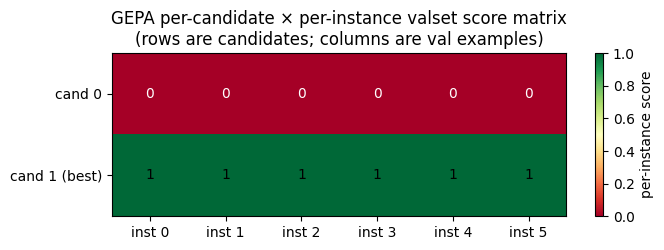

In [11]:
fig, ax = plt.subplots(figsize=(7, 2 + 0.3 * n_cand))
im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(n_inst))
ax.set_xticklabels(score_df.columns)
ax.set_yticks(range(n_cand))
ax.set_yticklabels(score_df.index)
for i in range(n_cand):
    for j in range(n_inst):
        ax.text(
            j,
            i,
            f"{mat[i, j]:.0f}",
            ha="center",
            va="center",
            color="white" if mat[i, j] < 0.5 else "black",
        )
plt.colorbar(im, ax=ax, label="per-instance score")
ax.set_title("GEPA per-candidate × per-instance valset score matrix\n(rows are candidates; columns are val examples)")
plt.tight_layout()
plt.show()

## 5. Reading the Pareto frontier from the matrix

The frontier is "for each instance, which candidates achieve the column max?" — `result.per_val_instance_best_candidates` answers exactly that.

In this run candidate 1 dominates candidate 0 on every instance (a strict improvement), so the frontier is `{1}` for all 6 instances — GEPA's `ParetoCandidateSelector` would always pick candidate 1 to mutate next. With more candidates and noisier scores, different columns would name different candidates and the selector would round-robin through them.

## 6. The whole thing as `to_dict` — for serialization or persistence

`result.to_dict()` is the kernel-namespace equivalent of "write this to disk." Look at its shape:

In [12]:
d = result.to_dict()
print("top-level keys:", list(d.keys()))
print()
for k, v in d.items():
    if isinstance(v, (list, dict)):
        print(f"  {k:<35} : {type(v).__name__:<10} len={len(v)}")
    else:
        rv = repr(v)
        print(f"  {k:<35} : {type(v).__name__:<10} {rv[:60]}")

top-level keys: ['candidates', 'parents', 'val_aggregate_scores', 'val_subscores', 'best_outputs_valset', 'per_val_instance_best
_candidates', 'val_aggregate_subscores', 'per_objective_best_candidates', 'objective_pareto_front', 'discovery_eval_counts', 'to
tal_metric_calls', 'num_full_val_evals', 'run_dir', 'seed', '_str_candidate_key', 'best_idx', 'validation_schema_version']

  candidates                          : list       len=2
  parents                             : list       len=2
  val_aggregate_scores                : list       len=2
  val_subscores                       : list       len=2
  best_outputs_valset                 : NoneType   None
  per_val_instance_best_candidates    : dict       len=6
  val_aggregate_subscores             : NoneType   None
  per_objective_best_candidates       : NoneType   None
  objective_pareto_front              : NoneType   None
  discovery_eval_counts               : list       len=2
  total_metric_calls                  : int        3

## Recap — what this notebook proved

The path this notebook walked, in the order the cells walked it:

- 1. Load a small GSM8K slice as `DefaultDataInst`
- 2. Run GEPA on GSM8K — small budget, real signal
- 3. Where do per-instance scores live on the result?
- 4. The Pareto heatmap
- 5. Reading the Pareto frontier from the matrix
- 6. The whole thing as `to_dict` — for serialization or persistence

Each step above was a real cell above. Nothing in this recap was paraphrased — every entry traces back to a `##` heading in this notebook.


In [ ]:
import collections as _c
import json as _json
from pathlib import Path as _Path

_nb_path = _Path("/Users/mhuang/Documents/GitHub/abook/notebooks/gepa/04-pareto-frontier-viz.ipynb")
_nb = _json.loads(_nb_path.read_text())
_cells = _nb["cells"]

# Cell type breakdown
_type_counts = _c.Counter(c["cell_type"] for c in _cells)

# Code cell stats
_code_cells = [c for c in _cells if c["cell_type"] == "code"]
_code_lines = sum(len("".join(c["source"]).splitlines()) for c in _code_cells)
_md_chars = sum(len("".join(c["source"])) for c in _cells if c["cell_type"] == "markdown")

# Output mime types seen
_mimes = _c.Counter()
_executed = 0
_errored = 0
for c in _code_cells:
    if c.get("execution_count") is not None:
        _executed += 1
    for out in c.get("outputs", []) or []:
        if out.get("output_type") == "error":
            _errored += 1
        for k in (out.get("data") or {}).keys():
            _mimes[k] += 1
        if out.get("output_type") == "stream":
            _mimes[f"stream:{out.get('name', 'stdout')}"] += 1

print(f"notebook        : {_nb_path.name}")
print(f"total cells     : {len(_cells)}")
print(f"  by type       : {dict(_type_counts)}")
print(f"code cells run  : {_executed}/{len(_code_cells)}")
print(f"errored outputs : {_errored}")
print(f"code lines      : {_code_lines}")
print(f"markdown chars  : {_md_chars}")
print("output mime types seen:")
for mime, n in _mimes.most_common():
    print(f"  {n:>3}  {mime}")

## Data sources

| Source | Path |
|---|---|
| GEPA library | `~/Documents/GitHub/abook/.venv/lib/python3.12/site-packages/gepa` |
| Eval data | HuggingFace `openai/gsm8k` (12 real items, 6 train + 6 val) |
| Task LM | `bedrock/converse/us.anthropic.claude-haiku-4-5-20251001-v1:0` |
| Reflection LM | `bedrock/converse/us.anthropic.claude-sonnet-4-5-20250929-v1:0` |
| Per-instance scores | `result.val_subscores` populated by real evaluation |

→ **Next:** [`05-custom-adapter.ipynb`](05-custom-adapter.ipynb) — write a `GEPAAdapter` subclass live and iterate on it without restart.